In [68]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import json
from tqdm import tqdm
from inference_interface import template_to_multihist
import scipy.stats as stats
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import Normalize
import sys
import pickle
import scipy
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LogNorm
from multihist import Hist1d
from alea.models import BlueiceExtendedModel


mpl.rcParams["figure.dpi"] = 200
mpl.rcParams["figure.figsize"] = [4, 3]
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.size"] = 9
mpl.rcParams["mathtext.fontset"] = "dejavuserif"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from utils import basis_nr, cs2_centers, cs2_edges, centers_to_edges, exposure_sr, patch_s2_only_model

# Compute the energy spectrum

First we choose a dark matter model of interest. Here we use the [wimprates](https://github.com/JelleAalbers/wimprates/tree/master) package to calculate the deposited energy in liquid xenon by a 6 GeV Halo dark matter with DM-nucleon cross section of $10^{-45}$ cm$^2$.

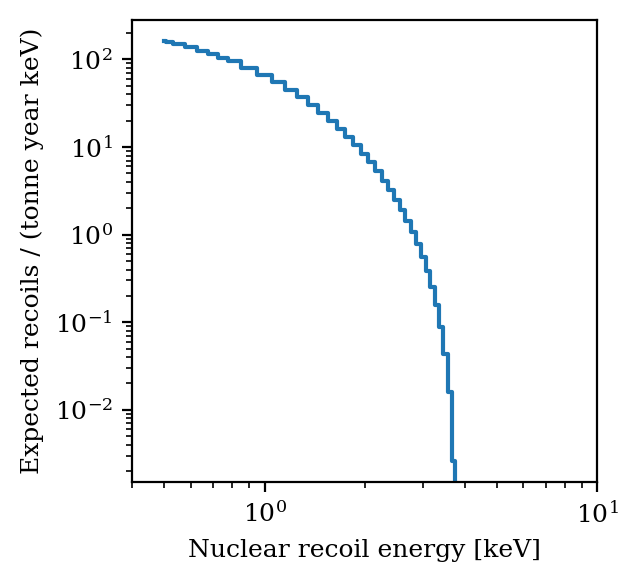

In [6]:
import wimprates as wr

reference_cross_section = 1e-45  # cm^2
dm_mass = 6 # GeV
signal_model = 'wimp_si'

# Compute the differential recoil spectrum in keV
rate_pertonneyearkev = wr.rate_wimp_std(
    es=basis_nr, 
    mw=dm_mass, 
    sigma_nucleon=reference_cross_section)

# Convert the rate per keV into rate per bin
energy_bin_width_kev = np.diff(centers_to_edges(basis_nr))
rate_pertonneyear_bin = rate_pertonneyearkev * energy_bin_width_kev

plt.figure(figsize=(3, 3))
plt.plot(basis_nr, rate_pertonneyearkev, drawstyle='steps-mid')
plt.xlabel("Nuclear recoil energy [keV]")
plt.ylabel("Expected recoils / (tonne year keV)")
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.4, 10)
plt.show()

# Convert to expected measured S2 rate

In [4]:
from inference_interface import multihist_to_template

In XENONnT, we simulate the observed spectrum on the cS2 (corrected ionization signal dimension) using `appletree`. For a data release, we distribute the observable for monoenergetic ER or NR signals. With the differential recoil energy spectrum, a simple dot product can simulate the detector response, casting the dark matter signal on the cS2 dimension.

Note that the signal comes with charge yield (number of electrons created per keV of recoil) uncertainties. The yield uncertainty is considered in the statistical model.

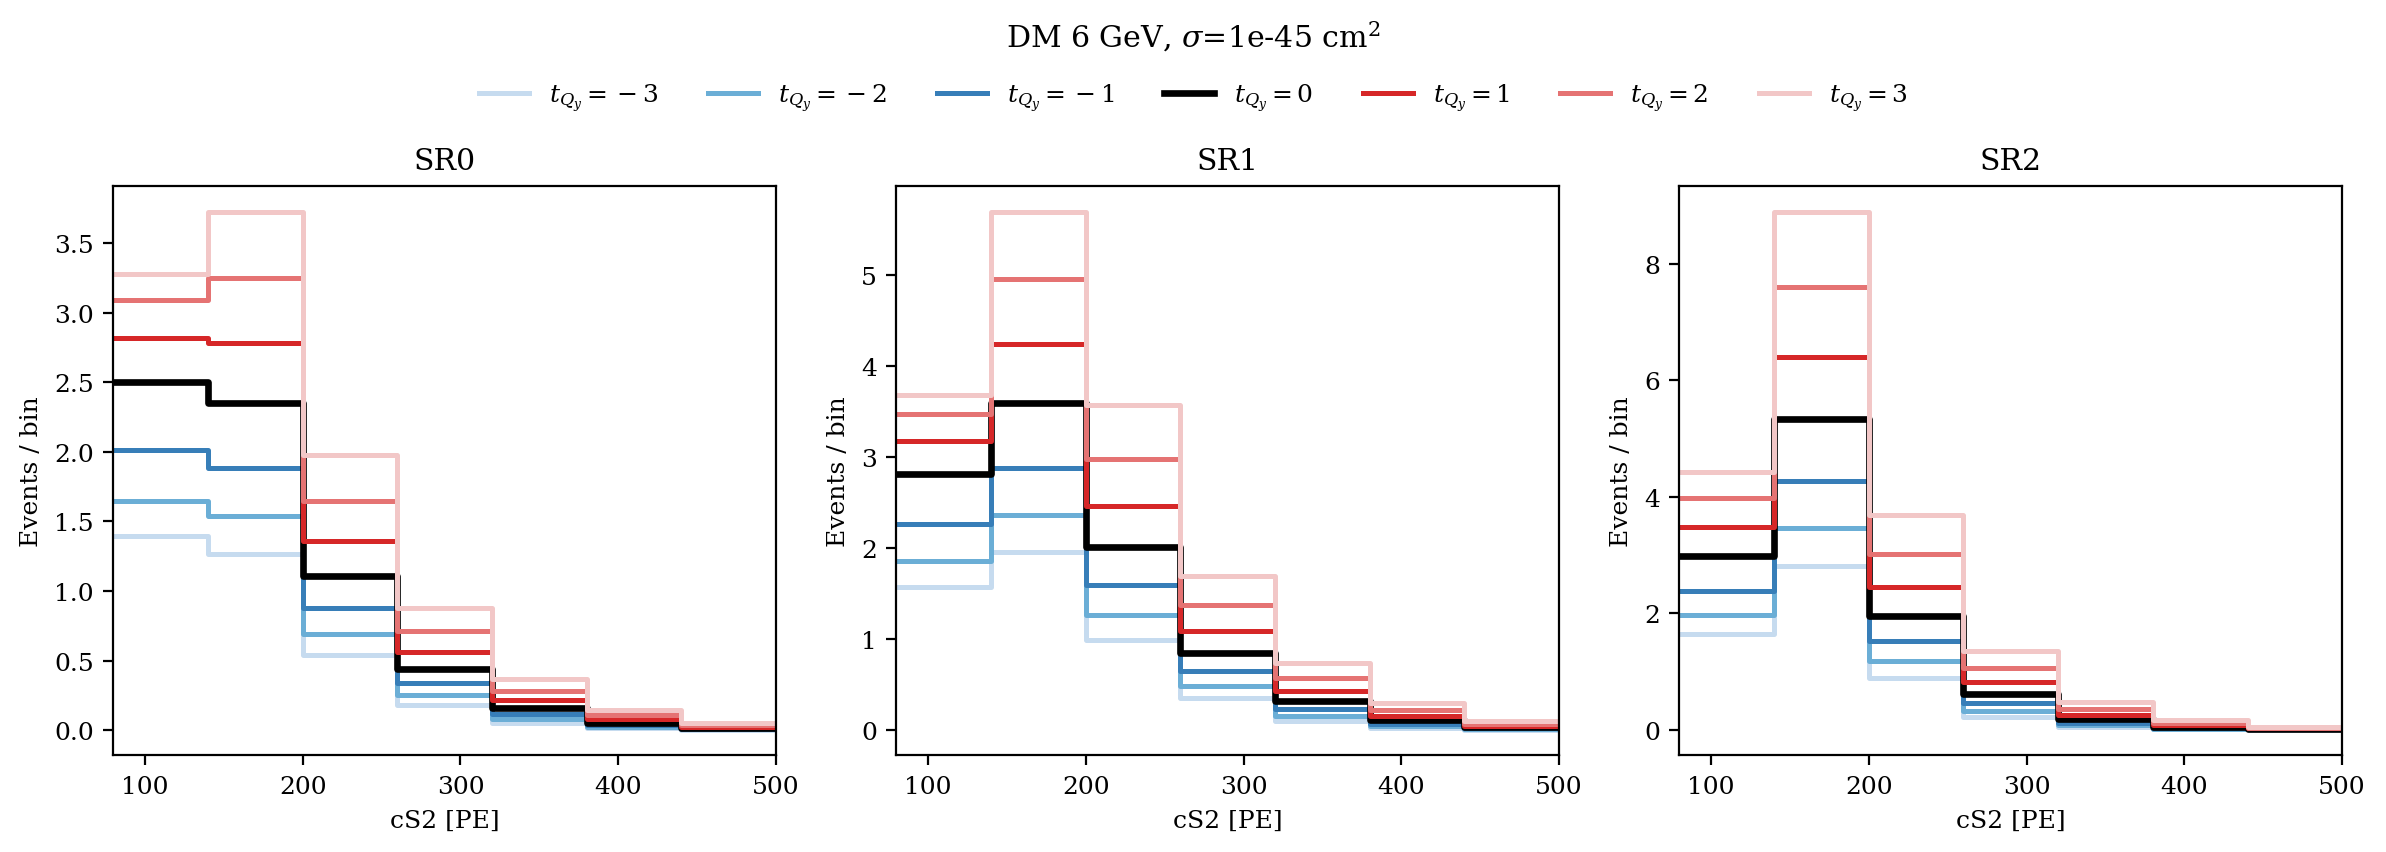

In [44]:
t = 'nr'  # Interaction type

shift_colors = {
    +3: "#f2c7c7",
    +2: "#e57373",
    +1: "#d62728",
     0: "black",
    -1: "#377eb8",
    -2: "#6baed6",
    -3: "#c6dbef",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, sr in enumerate(['sr0', 'sr1', 'sr2']):

    ax = axes[i]

    for tqy in [-3, -2, -1, 0, 1, 2, 3]:
        response = pd.read_csv(f'response/response_{t}_tqy_{tqy}_{sr}.csv')
        energy_kev = response['energy_kev'].values
        response_matrix = response.values[:, 1:]
        rate_s2 = np.dot(response_matrix.T, rate_pertonneyear_bin)

        mh_1d = Hist1d(bins=cs2_edges)
        mh_1d.histogram = rate_s2
        multihist_to_template(
            [mh_1d],
            f'./data/templates/template_XENONnT_{sr}_{signal_model}_{dm_mass:d}_tqy_{tqy:d}_1d.h5',
            ["template"],
            hist_to_store=Hist1d,
        )

        y = rate_s2 * exposure_sr[sr]
        y_step = np.r_[y, y[-1]]

        ax.step(
            cs2_edges,
            y_step,
            where='post',
            color=shift_colors[tqy],
            lw=1.8 if tqy != 0 else 2.4,
            label=fr'$t_{{Q_y}}={tqy}$' if sr == 'sr0' else None
        )

    ax.set_title(sr.upper())
    ax.set_xlim(80, 500)
    ax.set_xlabel('cS2 [PE]')
    ax.set_ylabel('Events / bin')

fig.legend(ncol=7, loc='upper center', bbox_to_anchor=(0.5, 1.), frameon=False)
fig.suptitle(f'DM {dm_mass} GeV, $\\sigma$={reference_cross_section} cm$^2$', y=1.05)

plt.tight_layout()
plt.show()

# Background models and Data

Compared to the XENON1T S2-only analysis, we are able to produce a complete background model.

In [74]:
with open('./data/real_data.pkl', 'rb') as file:
    _data = pickle.load(file)

data = dict()
for sr in ['sr0', 'sr1', 'sr2']:
    data[sr] = _data[sr.upper()]['cs2_wo_elifecorr']

Computing/loading models on one core:   0%|          | 0/686 [31:30<?, ?it/s]


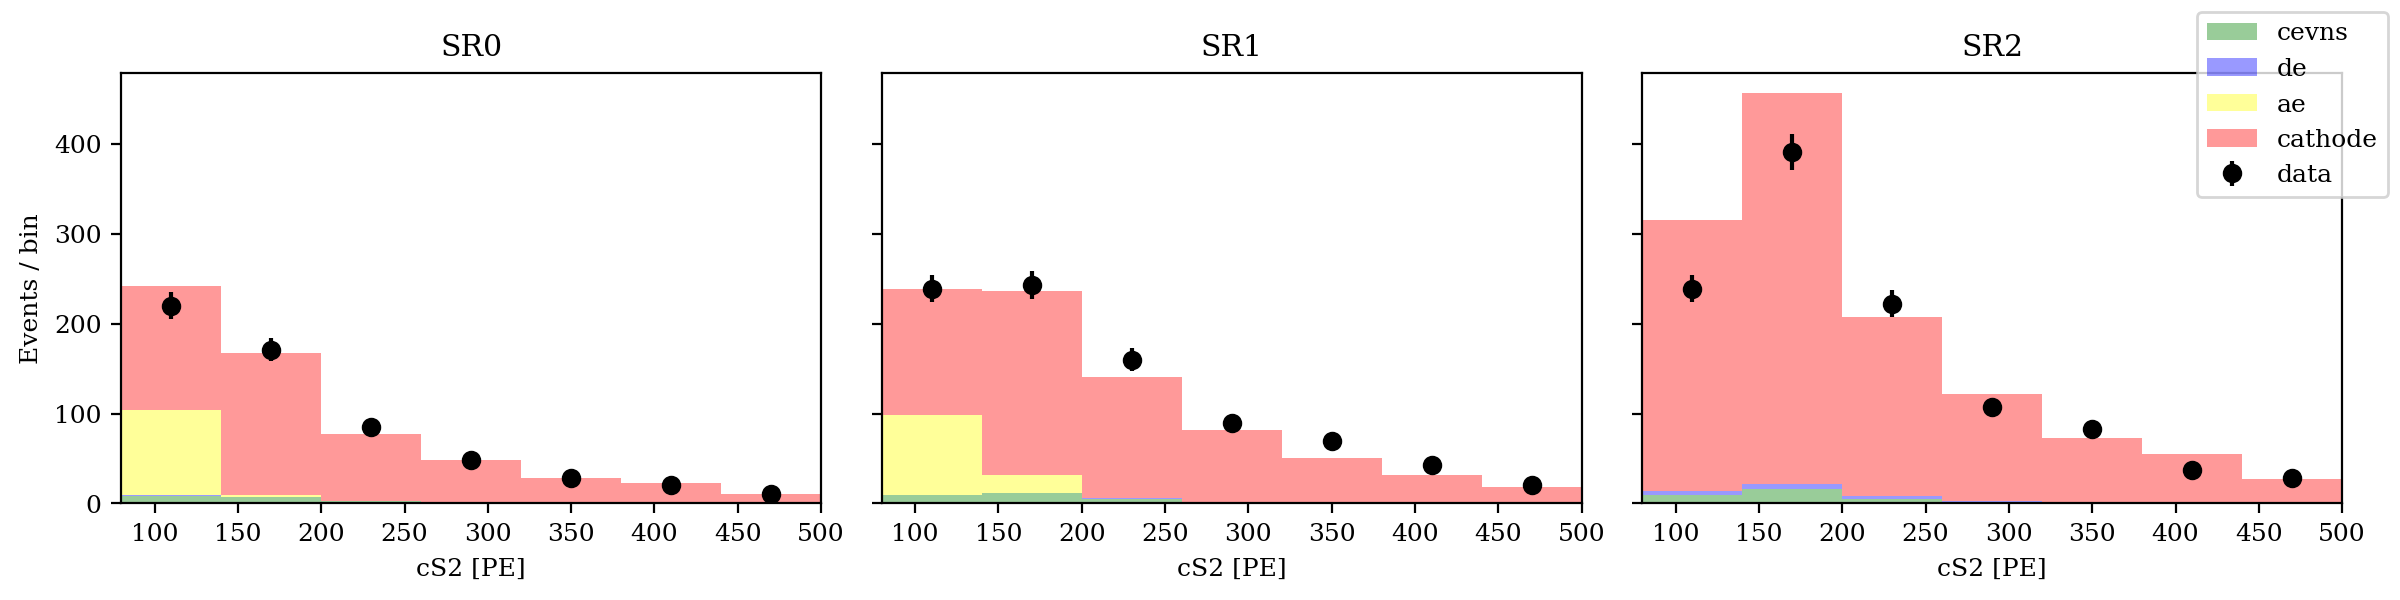

In [75]:
components = ['cevns', 'de', 'ae', 'cathode']
colors = ['green', 'blue', 'yellow', 'red']
color_dict = dict(zip(components, colors))

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for k, sr in enumerate(['sr0', 'sr1', 'sr2']):

    ax = axes[k]
    bkg = pd.read_csv(f'./data/background_{sr}.csv')

    bottom = np.zeros(len(cs2_centers), dtype=float)

    for j in range(len(bkg)):
        comp = bkg.iloc[j, 0]
        y = bkg.iloc[j, 1:].to_numpy(dtype=float) * exposure_sr[sr]

        ax.bar(
            cs2_centers,
            y,
            width=np.diff(cs2_edges),
            bottom=bottom,
            color=color_dict.get(comp, 'gray'),
            alpha=0.4,
            label=comp if k == 0 else None,
        )

        bottom += y

    counts, _ = np.histogram(data[sr], bins=cs2_edges)
    ax.errorbar(
        cs2_centers,
        counts,
        yerr=np.sqrt(counts),
        fmt='ko',
        label='data' if k == 0 else None,
    )

    ax.set_title(sr.upper())
    ax.set_xlim(80, 500)
    ax.set_xlabel('cS2 [PE]')

axes[0].set_ylabel('Events / bin')
fig.legend()
plt.tight_layout()
plt.show()


# Compute limits

By now the detector response model, background model, and observed data are all presented. One could in principle derive an interesting physics result using custom signal model and statistical tools.

On the other hand, the full likelihood in the XENONnT analysis is built with the [alea](https://github.com/XENONnT/alea) package to develop the binned log likelihood considering the nuissance parameter uncertainties.
A related documentation on how to recast the limits using alea is in [our previous S1--S2 search data release](https://github.com/XENONnT/light_wimp_data_release/blob/master/notebooks/2.%20Inference.ipynb).

Below we show how to compute a limit.

In [72]:
import alea

In [66]:
# Load the statistical model config, see the details in the yaml file, documenting where templates are saved and the rate/shape uncertainties.
config_path = f'./s2_only_statistical_model.yaml'
config = alea.utils.load_yaml(config_path)
config['parameter_definition']['wimp_mass']['nominal_value'] = dm_mass
config['parameter_definition']['wimp_mass']['blueice_anchors'] = [dm_mass]

# remove pdf_cache when you rerun an inference
# Initiate the model
model = BlueiceExtendedModel(parameter_definition=config['parameter_definition'], 
                                 likelihood_config=config['likelihood_config'],
                                 confidence_level=0.9,
                                 confidence_interval_kind='central',
                                 template_path=os.path.join(os.getcwd(), 'data/templates'))

# Put in the observed data
with open('./data/real_data.pkl', 'rb') as file:
    data = pickle.load(file)
data = patch_s2_only_model(data)
model.data = data

INFO:root:Load template_XENONnT_sr0_wimp_si_{wimp_mass:d}_tqy_{t_qy:d}_1d.h5 successfully from /home/shenyangshi/s2_only_data_release/data/templates/template_XENONnT_sr0_wimp_si_{wimp_mass:d}_tqy_{t_qy:d}_1d.h5
INFO:root:Load template_XENONnT_sr0_wimp_si_{wimp_mass:d}_tqy_{t_qy:d}_1d.h5 successfully from /home/shenyangshi/s2_only_data_release/data/templates/template_XENONnT_sr0_wimp_si_{wimp_mass:d}_tqy_{t_qy:d}_1d.h5
INFO:root:Load science_roi_background_sr0_template_cathode_tsys_{t_sys_sr0:d}_1d.h5 successfully from /home/shenyangshi/s2_only_data_release/data/templates/science_roi_background_sr0_template_cathode_tsys_{t_sys_sr0:d}_1d.h5
INFO:root:Load science_roi_background_sr0_template_cathode_tsys_{t_sys_sr0:d}_1d.h5 successfully from /home/shenyangshi/s2_only_data_release/data/templates/science_roi_background_sr0_template_cathode_tsys_{t_sys_sr0:d}_1d.h5
INFO:root:Load science_roi_background_sr0_template_de_1d.h5 successfully from /home/shenyangshi/s2_only_data_release/data/templa

In [67]:
# Compute the lower and upper limits
dl, ul = model.confidence_interval(
    poi_name="wimp_rate_multiplier",
)

100%|██████████| 30/30 [01:57<00:00,  3.91s/it]

-inf 2.97910848272258


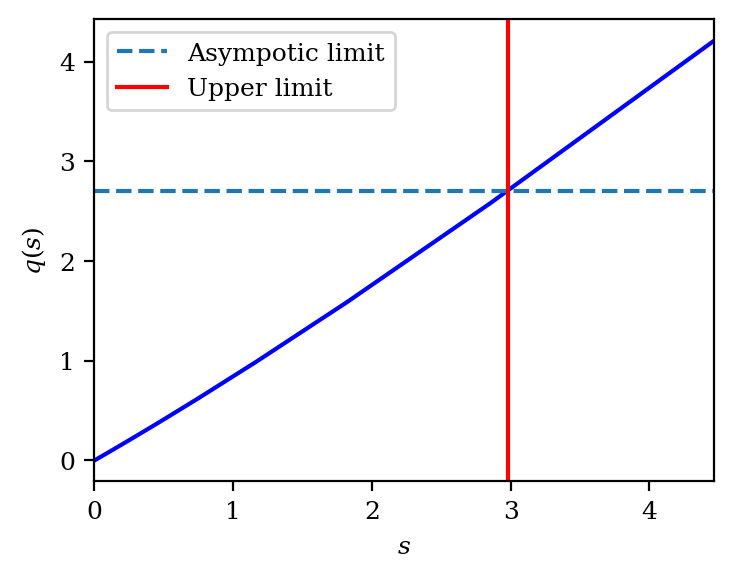

In [71]:
# Scan the likelihood function

plt.figure(figsize=(4, 3))

_best_fit, _ll_free = model.fit()
_null_fit, _ll_zero = model.fit(wimp_rate_multiplier=0)

# plot the profile-likelihood scan
s_vals=np.geomspace(1e-5, ul * 1.5, 30)
ll_vals_c = []
for s in tqdm(s_vals):
    _best_fit, ll_val_c = model.fit(wimp_rate_multiplier=s)
    ll_vals_c.append(ll_val_c)

ll_vals_c = np.array(ll_vals_c)
plt.plot(s_vals, 2 * (_ll_free - ll_vals_c), color='blue')
plt.axhline(scipy.stats.chi2(1).ppf(0.9), label='Asympotic limit', ls='--')
print(dl, ul)
plt.axvline(ul, label="Upper limit", color='red')

plt.legend()
plt.xlim(0, ul * 1.5)
plt.xlabel("$s$")
plt.ylabel("$q(s)$")
plt.show()


In [73]:
# The upper limit is subsequently, which matches the derived limits before power constraints
# Note in the actual analysis, we build Feldman-Cousins Confidence Intervals by calculating the threshold of test statistics corresponding to the 90% UL.
# So here is a conservative approximate treatment

ul * reference_cross_section

2.97910848272258e-45

We give no guarantees this is true for all signal models, particularly signal models with energy spectra that drop very steeply compared to the provided energy binning.